BERT model loading and fine tuning process


In [3]:
%pip install ipywidgets


   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 30.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


BERT model fine tuning process using LIAR training dataset.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
import torch

In [ ]:
train_df = pd.read_csv("./LIAR dataset/train modified.tsv", sep="\t")
valid_df = pd.read_csv("./LIAR dataset/valid modified.tsv", sep="\t")
test_df = pd.read_csv("./LIAR dataset/test modified.tsv", sep="\t")

In [ ]:
train_df.head()

,id,label,statement,subjects,speaker,speaker-job-title,state-info,party-affiliation,total-credit-history,false-counts,half-true-counts,mostly-true-counts,pants-on-fire-counts,location
0,2635.json,FALSE,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,FALSE,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [ ]:
true_labels = ["TRUE", "mostly-true"]

def convert_label(label):
    return 1 if label in true_labels else 0
 
for df in [train_df, valid_df, test_df]:
    df["label"] = df["label"].apply(convert_label)


In [10]:
train_df.head()

,id,label,statement,subjects,speaker,speaker-job-title,state-info,party-affiliation,total-credit-history,false-counts,half-true-counts,mostly-true-counts,pants-on-fire-counts,location
0,2635.json,0,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,0,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,1,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,0,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,0,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [ ]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize_dataset(df):
    return tokenizer(
        df["statement"].tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_encodings = tokenize_dataset(train_df)
valid_encodings = tokenize_dataset(valid_df)
test_encodings = tokenize_dataset(test_df)


In [ ]:
import torch

class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()} | {"labels": torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = FakeNewsDataset(train_encodings, train_df["label"].tolist())
valid_dataset = FakeNewsDataset(valid_encodings, valid_df["label"].tolist())
test_dataset = FakeNewsDataset(test_encodings, test_df["label"].tolist())

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


c:\Users\alber\anaconda3\envs\ai-testing\lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.628100,0.597177,0.679907,0.513846,0.397619,0.448322
2,0.556600,0.595144,0.683801,0.519231,0.450000,0.482143
3,0.421100,0.685053,0.673676,0.501241,0.480952,0.490887


TrainOutput(global_step=1920, training_loss=0.535285743077596, metrics={'train_runtime': 794.3569, 'train_samples_per_second': 38.673, 'train_steps_per_second': 2.417, 'total_flos': 2020692905164800.0, 'train_loss': 0.535285743077596, 'epoch': 3.0})

In [ ]:
test_metrics = trainer.evaluate(test_dataset)
print("Test Set Evaluation Metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")


Test Set Evaluation Metrics:
eval_loss: 0.6125
eval_accuracy: 0.6701
eval_precision: 0.5392
eval_recall: 0.4744
eval_f1: 0.5047
eval_runtime: 8.3474
eval_samples_per_second: 151.7840
eval_steps_per_second: 4.7920
epoch: 3.0000


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       818
           1       0.54      0.47      0.50       449

    accuracy                           0.67      1267
   macro avg       0.63      0.63      0.63      1267
weighted avg       0.66      0.67      0.66      1267



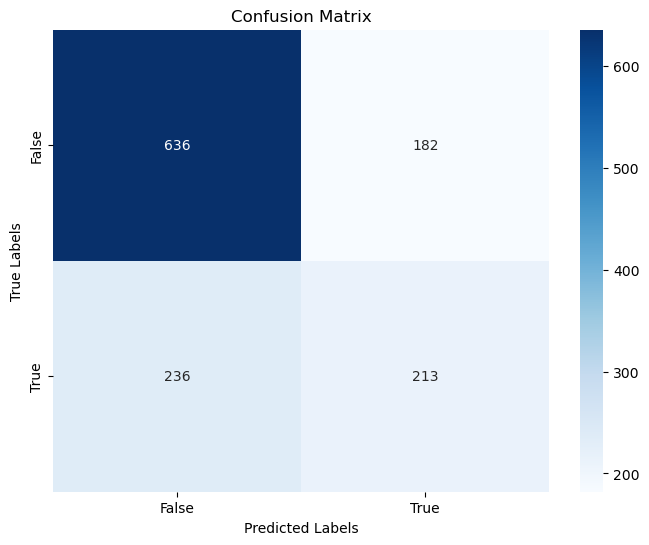

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

labels = ['False', 'True']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
model.save_pretrained("bert_liar_model")
tokenizer.save_pretrained("bert_liar_model")

('bert_liar_model\\tokenizer_config.json',
 'bert_liar_model\\special_tokens_map.json',
 'bert_liar_model\\vocab.txt',
 'bert_liar_model\\added_tokens.json',
 'bert_liar_model\\tokenizer.json')

LIAR + R Fine Tuning process


This fine tuning process uses a shuffled and combined dataset with both liar and renew training datasets


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

df_ft2_file_path = './LIAR dataset/liar and renew mixed - training.csv'

df_ft2_full = pd.read_csv(df_ft2_file_path)

print("Total records:", len(df_ft2_full))
print(df_ft2_full.head())

df_ft2_train, df_ft2_val = train_test_split(
    df_ft2_full,
    test_size=0.2,
    stratify=df_ft2_full['label'],
    random_state=42
)

df_ft2_train = df_ft2_train.reset_index(drop=True)
df_ft2_val = df_ft2_val.reset_index(drop=True)

Total records: 12344
                                           statement  label
0  Things went wrong with the Medicare prescripti...      1
1  I believe in a woman's right to choose. I alwa...      0
2  There are actually only 30 countries that prac...      1
3  Discretionary spending went up 84 percent in t...      0
4  To give the proposed economic stimulus plan so...      1


In [ ]:
from transformers import BertTokenizer
from datasets import Dataset

df_ft2_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

df_ft2_train_dataset = Dataset.from_pandas(df_ft2_train)
df_ft2_val_dataset = Dataset.from_pandas(df_ft2_val)

def df_ft2_tokenize_function(example):
    return df_ft2_tokenizer(
        example["statement"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

df_ft2_train_dataset = df_ft2_train_dataset.map(df_ft2_tokenize_function, batched=True)
df_ft2_val_dataset = df_ft2_val_dataset.map(df_ft2_tokenize_function, batched=True)

df_ft2_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
df_ft2_val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/9875 [00:00<?, ? examples/s]

Map:   0%|          | 0/2469 [00:00<?, ? examples/s]

In [ ]:

import torch
from transformers import BertForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

df_ft2_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

df_ft2_output_dir = "./fine tuned bert liar renew model"
os.makedirs(df_ft2_output_dir, exist_ok=True)

df_ft2_training_args = TrainingArguments(
    output_dir=df_ft2_output_dir,
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir=os.path.join(df_ft2_output_dir, "logs"),
    logging_strategy="steps",       
    logging_steps=200,              
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    gradient_accumulation_steps=2,
    report_to="none"                
)

def df_ft2_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


df_ft2_tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased", 
    truncation=True, 
    padding=True,  
    max_length=128
)

df_ft2_trainer = Trainer(
    model=df_ft2_model,
    args=df_ft2_training_args,
    train_dataset=df_ft2_train_dataset,
    eval_dataset=df_ft2_val_dataset,
    tokenizer=df_ft2_tokenizer,
    compute_metrics=df_ft2_compute_metrics
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\alber\AppData\Local\Temp\ipykernel_6560\2486695773.py:208: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  df_ft2_trainer = Trainer(


In [ ]:
df_ft2_trainer.train()

df_ft2_trainer.save_model(df_ft2_output_dir)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.623000,0.599802,0.661806,0.551449,0.588486,0.569366


Evaluating fine tuned in mixed LIAR + R over: ReNew Test


In [ ]:
import pandas as pd
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch

df_ft2_test_df = pd.read_csv('./ReNew dataset/combined renew test.csv')

class df_ft2_TestDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

df_ft2_test_encodings = df_ft2_tokenizer(
    df_ft2_test_df['statement'].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

df_ft2_test_labels = df_ft2_test_df['label'].tolist()

df_ft2_test_dataset = df_ft2_TestDataset(df_ft2_test_encodings, df_ft2_test_labels)

df_ft2_preds_output = df_ft2_trainer.predict(df_ft2_test_dataset)
df_ft2_preds = torch.argmax(torch.tensor(df_ft2_preds_output.predictions), dim=1).numpy()

accuracy = accuracy_score(df_ft2_test_labels, df_ft2_preds)
precision = precision_score(df_ft2_test_labels, df_ft2_preds)
recall = recall_score(df_ft2_test_labels, df_ft2_preds)
f1 = f1_score(df_ft2_test_labels, df_ft2_preds)
tn, fp, fn, tp = confusion_matrix(df_ft2_test_labels, df_ft2_preds).ravel()
specificity = tn / (tn + fp)

print("=== Evaluation on Combined Renew Test Set ===")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"Specificity: {specificity:.4f}")


=== Evaluation on Combined Renew Test Set ===
Accuracy   : 0.7913
Precision  : 0.8532
Recall     : 0.7045
F1 Score   : 0.7718
Specificity: 0.8783


Evaluating fine tuned in mixed LIAR + R over: LIAR Test


In [ ]:
import pandas as pd
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch

liar_test_df = pd.read_csv('./LIAR dataset/cleaned_test.csv')

class LiarTestDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

liar_test_encodings = df_ft2_tokenizer(
    liar_test_df['statement'].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

liar_test_labels = liar_test_df['label'].tolist()

liar_test_dataset = LiarTestDataset(liar_test_encodings, liar_test_labels)

liar_test_preds_output = df_ft2_trainer.predict(liar_test_dataset)
liar_test_preds = torch.argmax(torch.tensor(liar_test_preds_output.predictions), dim=1).numpy()

accuracy = accuracy_score(liar_test_labels, liar_test_preds)
precision = precision_score(liar_test_labels, liar_test_preds)
recall = recall_score(liar_test_labels, liar_test_preds)
f1 = f1_score(liar_test_labels, liar_test_preds)
tn, fp, fn, tp = confusion_matrix(liar_test_labels, liar_test_preds).ravel()
specificity = tn / (tn + fp)

print("=== Evaluation on LIAR Test Set ===")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"Specificity: {specificity:.4f}")


=== Evaluation on LIAR Test Set ===
Accuracy   : 0.6646
Precision  : 0.5248
Recall     : 0.5657
F1 Score   : 0.5445
Specificity: 0.7188
